In [2]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
#Dataset Paths

PROJECT_ROOT = Path.cwd().parent.parent

DATASET_DIR = PROJECT_ROOT / "data"

PCB_USED_DIR = DATASET_DIR / "raw" / "PCB_USED"

IMAGES_DIR = DATASET_DIR / "raw" / "Images"

ANNOTATIONS_DIR = DATASET_DIR / "raw" / "Annotations"


print("Project Root:")
print(PROJECT_ROOT)

print("\nPCB_USED:")
print(PCB_USED_DIR)

print("\nImages:")
print(IMAGES_DIR)

print("\nAnnotations:")
print(ANNOTATIONS_DIR)

Project Root:
c:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection

PCB_USED:
c:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\raw\PCB_USED

Images:
c:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\raw\Images

Annotations:
c:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\raw\Annotations


In [4]:
# Train / Validation / Test Split
# PCB IDs used for each split

TRAIN_PCB_IDS = [
    "01",
    "05",
    "06",
    "07",
    "08",
    "09",
    "11"
]

VAL_PCB_IDS = [
    "12"
]

TEST_PCB_IDS = [
    "04",
    "10"
]


print("TRAIN PCB IDs:")
print(TRAIN_PCB_IDS)

print("\nVALIDATION PCB IDs:")
print(VAL_PCB_IDS)

print("\nTEST PCB IDs:")
print(TEST_PCB_IDS)

TRAIN PCB IDs:
['01', '05', '06', '07', '08', '09', '11']

VALIDATION PCB IDs:
['12']

TEST PCB IDs:
['04', '10']


In [5]:
# ==========================================
# Check PCB references
# ==========================================

print("\nChecking PCB_USED references...")

for pcb_id in TRAIN_PCB_IDS:

    print(
        "Train:",
        pcb_id,
        "→",
        (PCB_USED_DIR / f"{pcb_id}.JPG").exists()
    )


for pcb_id in VAL_PCB_IDS:

    print(
        "Validation:",
        pcb_id,
        "→",
        (PCB_USED_DIR / f"{pcb_id}.JPG").exists()
    )


for pcb_id in TEST_PCB_IDS:

    print(
        "Test:",
        pcb_id,
        "→",
        (PCB_USED_DIR / f"{pcb_id}.JPG").exists()
    )


Checking PCB_USED references...
Train: 01 → True
Train: 05 → True
Train: 06 → True
Train: 07 → True
Train: 08 → True
Train: 09 → True
Train: 11 → True
Validation: 12 → True
Test: 04 → True
Test: 10 → True


In [6]:
# ==========================================
# Cell 4: Create YOLO Dataset Structures
# ==========================================

DATASET_BASE_DIR = (
    PROJECT_ROOT
    / "data"
    / "clean"
)


# ==========================================
# Parameter Set Directories
# ==========================================

SET1_DIR = (
    DATASET_BASE_DIR
    / "dataset_limszeping_set1"
)

SET2_DIR = (
    DATASET_BASE_DIR
    / "dataset_limszeping_set2"
)

SET3_DIR = (
    DATASET_BASE_DIR
    / "dataset_limszeping_set3"
)


# ==========================================
# Function: Create YOLO Dataset Structure
# ==========================================

def create_yolo_structure(dataset_dir):

    # --------------------------------------
    # Image folders
    # --------------------------------------

    train_images = (
        dataset_dir
        / "images"
        / "train"
    )

    val_images = (
        dataset_dir
        / "images"
        / "val"
    )

    test_images = (
        dataset_dir
        / "images"
        / "test"
    )


    # --------------------------------------
    # Label folders
    # --------------------------------------

    train_labels = (
        dataset_dir
        / "labels"
        / "train"
    )

    val_labels = (
        dataset_dir
        / "labels"
        / "val"
    )

    test_labels = (
        dataset_dir
        / "labels"
        / "test"
    )


    # --------------------------------------
    # Create folders
    # --------------------------------------

    train_images.mkdir(
        parents=True,
        exist_ok=True
    )

    val_images.mkdir(
        parents=True,
        exist_ok=True
    )

    test_images.mkdir(
        parents=True,
        exist_ok=True
    )

    train_labels.mkdir(
        parents=True,
        exist_ok=True
    )

    val_labels.mkdir(
        parents=True,
        exist_ok=True
    )

    test_labels.mkdir(
        parents=True,
        exist_ok=True
    )


# ==========================================
# Create all 3 dataset structures
# ==========================================

create_yolo_structure(
    SET1_DIR
)

create_yolo_structure(
    SET2_DIR
)

create_yolo_structure(
    SET3_DIR
)


# ==========================================
# Display Result
# ==========================================

print("YOLO dataset structures created.")
print()

print("Set 1:")
print(SET1_DIR)

print()

print("Set 2:")
print(SET2_DIR)

print()

print("Set 3:")
print(SET3_DIR)

YOLO dataset structures created.

Set 1:
c:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1

Set 2:
c:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set2

Set 3:
c:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set3


In [7]:
# ==========================================
# Cell 5: Define YOLO Defect Classes
# ==========================================

defect_classes = [
    "Missing_hole",
    "Mouse_bite",
    "Open_circuit",
    "Short",
    "Spur",
    "Spurious_copper"
]


# ==========================================
# Assign YOLO Class IDs
# ==========================================

class_ids = {
    "Missing_hole": 0,
    "Mouse_bite": 1,
    "Open_circuit": 2,
    "Short": 3,
    "Spur": 4,
    "Spurious_copper": 5
}


# ==========================================
# Display Classes
# ==========================================

print("YOLO Classes:")

for class_name, class_id in class_ids.items():

    print(
        class_id,
        "->",
        class_name
    )

YOLO Classes:
0 -> Missing_hole
1 -> Mouse_bite
2 -> Open_circuit
3 -> Short
4 -> Spur
5 -> Spurious_copper


In [8]:
# ==========================================
# Cell 6: Parameter Configurations
# CLAHE + Gamma + Laplacian Sharpening
# ==========================================


# ==========================================
# Experiment 1
# ==========================================

PARAMETER_SET_1 = {

    "clahe_clip_limit": 1.5,

    "gamma": 1.0,

    "laplacian_weight": -0.5

}


# ==========================================
# Experiment 2
# ==========================================

PARAMETER_SET_2 = {

    "clahe_clip_limit": 2.0,

    "gamma": 1.2,

    "laplacian_weight": -0.7

}


# ==========================================
# Experiment 3
# ==========================================

PARAMETER_SET_3 = {

    "clahe_clip_limit": 3.0,

    "gamma": 1.4,

    "laplacian_weight": -1.0

}


# ==========================================
# Display Parameter Configurations
# ==========================================

print("==========================================")
print("Parameter Configurations")
print("==========================================")


print("\nExperiment 1:")
print(
    "CLAHE Clip Limit:",
    PARAMETER_SET_1["clahe_clip_limit"]
)
print(
    "Gamma:",
    PARAMETER_SET_1["gamma"]
)
print(
    "Laplacian Weight:",
    PARAMETER_SET_1["laplacian_weight"]
)


print("\nExperiment 2:")
print(
    "CLAHE Clip Limit:",
    PARAMETER_SET_2["clahe_clip_limit"]
)
print(
    "Gamma:",
    PARAMETER_SET_2["gamma"]
)
print(
    "Laplacian Weight:",
    PARAMETER_SET_2["laplacian_weight"]
)


print("\nExperiment 3:")
print(
    "CLAHE Clip Limit:",
    PARAMETER_SET_3["clahe_clip_limit"]
)
print(
    "Gamma:",
    PARAMETER_SET_3["gamma"]
)
print(
    "Laplacian Weight:",
    PARAMETER_SET_3["laplacian_weight"]
)


print("\n==========================================")
print("Pipeline:")
print("CLAHE -> Gamma Correction -> Laplacian Sharpening")
print("==========================================")

Parameter Configurations

Experiment 1:
CLAHE Clip Limit: 1.5
Gamma: 1.0
Laplacian Weight: -0.5

Experiment 2:
CLAHE Clip Limit: 2.0
Gamma: 1.2
Laplacian Weight: -0.7

Experiment 3:
CLAHE Clip Limit: 3.0
Gamma: 1.4
Laplacian Weight: -1.0

Pipeline:
CLAHE -> Gamma Correction -> Laplacian Sharpening


In [9]:
# ==========================================
# Cell 7: Enhancement Function
# ==========================================

def enhance_pcb(
    image,
    clahe_clip_limit,
    gamma,
    laplacian_weight
):

    # ======================================
    # 1. Convert to Grayscale
    # ======================================

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # ======================================
    # 2. CLAHE
    # ======================================

    clahe = cv2.createCLAHE(
        clipLimit=clahe_clip_limit,
        tileGridSize=(8, 8)
    )

    clahe_image = clahe.apply(
        gray
    )


    # ======================================
    # 3. Gamma Correction
    # ======================================

    gamma_table = np.array(
        [
            ((i / 255.0) ** (1.0 / gamma)) * 255
            for i in range(256)
        ]
    ).astype(
        np.uint8
    )

    gamma_image = cv2.LUT(
        clahe_image,
        gamma_table
    )


    # ======================================
    # 4. Laplacian Sharpening
    # ======================================

    laplacian = cv2.Laplacian(
        gamma_image,
        cv2.CV_64F
    )

    laplacian_abs = cv2.convertScaleAbs(
        laplacian
    )

    sharpened = cv2.addWeighted(
        gamma_image,
        1.0,
        laplacian_abs,
        laplacian_weight,
        0
    )


    return sharpened


print("Enhancement function is ready.")

print(
    "Pipeline:"
)

print(
    "CLAHE -> Gamma Correction -> Laplacian Sharpening"
)

Enhancement function is ready.
Pipeline:
CLAHE -> Gamma Correction -> Laplacian Sharpening


In [10]:
# ==========================================
# Cell 8: Load Sample Images for Testing
# ==========================================

# ==========================================
# Define Dataset Paths
# ==========================================

IMAGES_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "images"
)

PCB_USED_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "PCB_USED"
)


# ==========================================
# Function: Get Image Files
# ==========================================

def get_image_files(folder):

    image_files = []

    for file in folder.iterdir():

        if file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:

            image_files.append(file)

    return sorted(image_files)


# ==========================================
# Function: Find Matching Normal PCB
# ==========================================

def find_normal_pcb(pcb_number):

    for file in PCB_USED_DIR.iterdir():

        if file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:

            if file.stem == pcb_number:

                return file

    return None


# ==========================================
# Select Defect Class
# ==========================================

sample_defect_class = "Missing_hole"


# ==========================================
# Get Defect Folder
# ==========================================

defect_folder = (
    IMAGES_DIR
    / sample_defect_class
)


# ==========================================
# Get Image Files
# ==========================================

image_files = get_image_files(
    defect_folder
)


print(
    "Images found:",
    len(image_files)
)


# ==========================================
# Check Images
# ==========================================

if len(image_files) == 0:

    print(
        "No images found in:",
        defect_folder
    )

else:

    # ======================================
    # Select First Defective Image
    # ======================================

    defective_path = image_files[0]


    # ======================================
    # Get PCB Number
    # ======================================

    pcb_number = defective_path.stem[:2]


    # ======================================
    # Find Matching Normal PCB
    # ======================================

    normal_path = find_normal_pcb(
        pcb_number
    )


    if normal_path is None:

        print(
            "Normal PCB not found for:",
            pcb_number
        )

    else:

        # ==================================
        # Load Images
        # ==================================

        normal = cv2.imread(
            str(normal_path)
        )

        defective = cv2.imread(
            str(defective_path)
        )


        # ==================================
        # Resize Defective Image
        # ==================================

        defective = cv2.resize(
            defective,
            (
                normal.shape[1],
                normal.shape[0]
            )
        )


        # ==================================
        # Display Information
        # ==================================

        print(
            "\n=========================================="
        )

        print(
            "Sample Images Loaded Successfully"
        )

        print(
            "=========================================="
        )

        print(
            "Defect Class:",
            sample_defect_class
        )

        print(
            "PCB Reference:",
            pcb_number
        )

        print(
            "Defective Image:",
            defective_path.name
        )

        print(
            "Normal Image:",
            normal_path.name
        )

        print(
            "=========================================="
        )

Images found: 115

Sample Images Loaded Successfully
Defect Class: Missing_hole
PCB Reference: 01
Defective Image: 01_missing_hole_01.jpg
Normal Image: 01.JPG


In [11]:
# ==========================================
# Cell 9: Compare 3 Parameter Configurations
# ==========================================

# ==========================================
# 1. Define Dataset Paths
# ==========================================

IMAGES_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "images"
)

PCB_USED_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "PCB_USED"
)


# ==========================================
# 2. Select Sample Defect
# ==========================================

sample_defect_class = "Missing_hole"


# ==========================================
# 3. Get Image Files
# ==========================================

defect_folder = (
    IMAGES_DIR
    / sample_defect_class
)


image_files = sorted(
    [
        file
        for file in defect_folder.iterdir()
        if file.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]
)


if len(image_files) == 0:

    raise FileNotFoundError(
        f"No images found in {defect_folder}"
    )


# ==========================================
# 4. Select First Defective Image
# ==========================================

defective_path = image_files[0]

pcb_number = defective_path.stem[:2]


# ==========================================
# 5. Find Matching Normal PCB
# ==========================================

normal_path = None


for file in PCB_USED_DIR.iterdir():

    if file.suffix.lower() in [
        ".jpg",
        ".jpeg",
        ".png"
    ]:

        if file.stem == pcb_number:

            normal_path = file
            break


if normal_path is None:

    raise FileNotFoundError(
        f"Normal PCB not found for PCB {pcb_number}"
    )


# ==========================================
# 6. Load Images
# ==========================================

normal = cv2.imread(
    str(normal_path)
)

defective = cv2.imread(
    str(defective_path)
)


if normal is None:

    raise ValueError(
        "Cannot load normal PCB image."
    )


if defective is None:

    raise ValueError(
        "Cannot load defective PCB image."
    )


# ==========================================
# 7. Resize Defective Image
# ==========================================

defective = cv2.resize(
    defective,
    (
        normal.shape[1],
        normal.shape[0]
    )
)


print("==========================================")
print("Sample Image Loaded")
print("==========================================")

print(
    "Defect Class:",
    sample_defect_class
)

print(
    "PCB Reference:",
    pcb_number
)

print(
    "Defective Image:",
    defective_path.name
)

print(
    "Normal Image:",
    normal_path.name
)

# 8. Define 3 Parameter Configurations

PARAMETER_SET_1 = {

    "clahe_clip_limit": 2.0,

    "gamma": 1.2,

    "laplacian_weight": -0.7
}


PARAMETER_SET_2 = {

    "clahe_clip_limit": 3.0,

    "gamma": 1.5,

    "laplacian_weight": -1.0
}


PARAMETER_SET_3 = {

    "clahe_clip_limit": 4.0,

    "gamma": 0.8,

    "laplacian_weight": -0.5
}


# ==========================================
# 9. Enhancement Function
# ==========================================

def enhance_pcb(
    image,
    clahe_clip_limit,
    gamma,
    laplacian_weight
):

    # --------------------------------------
    # Convert to grayscale
    # --------------------------------------

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------
    # CLAHE
    # --------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=clahe_clip_limit,
        tileGridSize=(8, 8)
    )

    clahe_image = clahe.apply(
        gray
    )


    # --------------------------------------
    # Gamma Correction
    # --------------------------------------

    gamma_table = np.array(
        [
            (
                (i / 255.0)
                ** (1.0 / gamma)
            ) * 255

            for i in range(256)
        ]
    ).astype(
        np.uint8
    )


    gamma_image = cv2.LUT(
        clahe_image,
        gamma_table
    )


    # --------------------------------------
    # Laplacian Sharpening
    # --------------------------------------

    laplacian = cv2.Laplacian(
        gamma_image,
        cv2.CV_64F
    )


    laplacian_abs = cv2.convertScaleAbs(
        laplacian
    )


    sharpened = cv2.addWeighted(
        gamma_image,
        1.0,
        laplacian_abs,
        laplacian_weight,
        0
    )


    return sharpened


# ==========================================
# 10. Apply Parameter Set 1
# ==========================================

normal_enhanced_1 = enhance_pcb(
    normal,
    PARAMETER_SET_1["clahe_clip_limit"],
    PARAMETER_SET_1["gamma"],
    PARAMETER_SET_1["laplacian_weight"]
)


defective_enhanced_1 = enhance_pcb(
    defective,
    PARAMETER_SET_1["clahe_clip_limit"],
    PARAMETER_SET_1["gamma"],
    PARAMETER_SET_1["laplacian_weight"]
)


# ==========================================
# 11. Apply Parameter Set 2
# ==========================================

normal_enhanced_2 = enhance_pcb(
    normal,
    PARAMETER_SET_2["clahe_clip_limit"],
    PARAMETER_SET_2["gamma"],
    PARAMETER_SET_2["laplacian_weight"]
)


defective_enhanced_2 = enhance_pcb(
    defective,
    PARAMETER_SET_2["clahe_clip_limit"],
    PARAMETER_SET_2["gamma"],
    PARAMETER_SET_2["laplacian_weight"]
)


# ==========================================
# 12. Apply Parameter Set 3
# ==========================================

normal_enhanced_3 = enhance_pcb(
    normal,
    PARAMETER_SET_3["clahe_clip_limit"],
    PARAMETER_SET_3["gamma"],
    PARAMETER_SET_3["laplacian_weight"]
)


defective_enhanced_3 = enhance_pcb(
    defective,
    PARAMETER_SET_3["clahe_clip_limit"],
    PARAMETER_SET_3["gamma"],
    PARAMETER_SET_3["laplacian_weight"]
)


# ==========================================
# 13. Convert Original Image to RGB
# ==========================================

defective_rgb = cv2.cvtColor(
    defective,
    cv2.COLOR_BGR2RGB
)


# ==========================================
# 14. Display Comparison
# ==========================================

plt.figure(
    figsize=(20, 10)
)


# ------------------------------------------
# Original
# ------------------------------------------

plt.subplot(2, 4, 1)

plt.imshow(
    defective_rgb
)

plt.title(
    "Original Defective PCB"
)

plt.axis("off")


# ------------------------------------------
# Parameter Set 1
# ------------------------------------------

plt.subplot(2, 4, 2)

plt.imshow(
    defective_enhanced_1,
    cmap="gray"
)

plt.title(
    "Parameter Set 1\n"
    "CLAHE=2.0 | Gamma=1.2 | Lap=-0.7"
)

plt.axis("off")


# ------------------------------------------
# Parameter Set 2
# ------------------------------------------

plt.subplot(2, 4, 3)

plt.imshow(
    defective_enhanced_2,
    cmap="gray"
)

plt.title(
    "Parameter Set 2\n"
    "CLAHE=3.0 | Gamma=1.5 | Lap=-1.0"
)

plt.axis("off")


# ------------------------------------------
# Parameter Set 3
# ------------------------------------------

plt.subplot(2, 4, 4)

plt.imshow(
    defective_enhanced_3,
    cmap="gray"
)

plt.title(
    "Parameter Set 3\n"
    "CLAHE=4.0 | Gamma=0.8 | Lap=-0.5"
)

plt.axis("off")


# ------------------------------------------
# Normal Set 1
# ------------------------------------------

plt.subplot(2, 4, 6)

plt.imshow(
    normal_enhanced_1,
    cmap="gray"
)

plt.title(
    "Normal - Set 1"
)

plt.axis("off")


# ------------------------------------------
# Normal Set 2
# ------------------------------------------

plt.subplot(2, 4, 7)

plt.imshow(
    normal_enhanced_2,
    cmap="gray"
)

plt.title(
    "Normal - Set 2"
)

plt.axis("off")


# ------------------------------------------
# Normal Set 3
# ------------------------------------------

plt.subplot(2, 4, 8)

plt.imshow(
    normal_enhanced_3,
    cmap="gray"
)

plt.title(
    "Normal - Set 3"
)

plt.axis("off")


plt.tight_layout()

plt.show()


# ==========================================
# 15. Print Parameters
# ==========================================

print("\n==========================================")
print("PARAMETER CONFIGURATIONS")
print("==========================================")

print(
    "Set 1:",
    PARAMETER_SET_1
)

print(
    "Set 2:",
    PARAMETER_SET_2
)

print(
    "Set 3:",
    PARAMETER_SET_3
)

print("==========================================")

Sample Image Loaded
Defect Class: Missing_hole
PCB Reference: 01
Defective Image: 01_missing_hole_01.jpg
Normal Image: 01.JPG


KeyboardInterrupt: 

In [ ]:
# ==========================================
# Cell 10: Process All Images
# Apply 3 Parameter Configurations
# ==========================================

import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm


# ==========================================
# 1. Define Source Dataset
# ==========================================

SOURCE_IMAGES_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "images"
)


# ==========================================
# 2. Define Dataset Split
# ==========================================

SPLIT_PCB_IDS = {

    "train": [
        "01",
        "05",
        "06",
        "07",
        "08",
        "09",
        "11"
    ],

    "val": [
        "12"
    ],

    "test": [
        "04",
        "10"
    ]
}


# ==========================================
# 3. Define Parameter Configurations
# ==========================================

PARAMETER_SETS = {

    "set1": {
        "clahe_clip_limit": 2.0,
        "gamma": 1.2,
        "laplacian_weight": -0.7
    },

    "set2": {
        "clahe_clip_limit": 3.0,
        "gamma": 1.5,
        "laplacian_weight": -1.0
    },

    "set3": {
        "clahe_clip_limit": 4.0,
        "gamma": 0.8,
        "laplacian_weight": -0.5
    }
}


# ==========================================
# 4. Enhancement Function
# ==========================================

def enhance_pcb(
    image,
    clahe_clip_limit,
    gamma,
    laplacian_weight
):

    # --------------------------------------
    # Convert to grayscale
    # --------------------------------------

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------
    # CLAHE
    # --------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=clahe_clip_limit,
        tileGridSize=(8, 8)
    )

    clahe_image = clahe.apply(gray)


    # --------------------------------------
    # Gamma Correction
    # --------------------------------------

    gamma_table = np.array(
        [
            (
                (i / 255.0)
                ** (1.0 / gamma)
            ) * 255

            for i in range(256)
        ]
    ).astype(np.uint8)


    gamma_image = cv2.LUT(
        clahe_image,
        gamma_table
    )


    # --------------------------------------
    # Laplacian Sharpening
    # --------------------------------------

    laplacian = cv2.Laplacian(
        gamma_image,
        cv2.CV_64F
    )

    laplacian_abs = cv2.convertScaleAbs(
        laplacian
    )

    sharpened = cv2.addWeighted(
        gamma_image,
        1.0,
        laplacian_abs,
        laplacian_weight,
        0
    )


    return sharpened


# ==========================================
# 5. Get All Image Files
# ==========================================

all_image_files = []

for defect_class in sorted(
    SOURCE_IMAGES_DIR.iterdir()
):

    if not defect_class.is_dir():
        continue

    for image_file in sorted(
        defect_class.iterdir()
    ):

        if image_file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:

            all_image_files.append(
                (defect_class.name, image_file)
            )


print("Total images found:", len(all_image_files))


# ==========================================
# 6. Determine Dataset Split
# ==========================================

def get_split(image_file):

    # Example:
    # 01_missing_hole_01.jpg
    # PCB ID = 01

    pcb_id = image_file.stem[:2]

    for split_name, pcb_ids in SPLIT_PCB_IDS.items():

        if pcb_id in pcb_ids:
            return split_name

    return None


# ==========================================
# 7. Process All Images
# ==========================================

processed_count = {

    "set1": 0,
    "set2": 0,
    "set3": 0
}


for defect_class, image_file in tqdm(
    all_image_files,
    desc="Processing images"
):

    split = get_split(image_file)


    if split is None:

        print(
            "Warning: PCB ID not assigned:",
            image_file.name
        )

        continue


    # --------------------------------------
    # Load image
    # --------------------------------------

    image = cv2.imread(
        str(image_file)
    )


    if image is None:

        print(
            "Cannot read:",
            image_file
        )

        continue


    # --------------------------------------
    # Apply all 3 parameter sets
    # --------------------------------------

    for set_name, params in PARAMETER_SETS.items():

        # Enhance image

        enhanced = enhance_pcb(
            image,
            params["clahe_clip_limit"],
            params["gamma"],
            params["laplacian_weight"]
        )


        # ----------------------------------
        # Output directory
        # ----------------------------------

        output_dir = (
            PROJECT_ROOT
            / "data"
            / "clean"
            / f"dataset_limszeping_{set_name}"
            / "images"
            / split
            / defect_class
        )


        output_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        # ----------------------------------
        # Save enhanced image
        # ----------------------------------

        output_path = (
            output_dir
            / image_file.name
        )


        cv2.imwrite(
            str(output_path),
            enhanced
        )


        processed_count[set_name] += 1


# ==========================================
# 8. Display Results
# ==========================================

print("\n==========================================")
print("PROCESSING COMPLETED")
print("==========================================")

for set_name, count in processed_count.items():

    print(
        f"{set_name}: {count} images"
    )

print("==========================================")


Total images found: 693


Processing images: 100%|██████████| 693/693 [05:19<00:00,  2.17it/s]


PROCESSING COMPLETED
set1: 693 images
set2: 693 images
set3: 693 images


In [ ]:
# ==========================================
# Cell 11: Segmentation for All 3 Sets
#
# Enhanced Images
#       ↓
# Difference
#       ↓
# Threshold
#       ↓
# Morphological Opening
#       ↓
# Defect Segmentation Mask
# ==========================================

import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm


# ==========================================
# 1. Parameter Sets
# ==========================================

PARAMETER_SET_NAMES = [
    "set1",
    "set2",
    "set3"
]


# ==========================================
# 2. Dataset Root
# ==========================================

CLEAN_DIR = (
    PROJECT_ROOT
    / "data"
    / "clean"
)


# ==========================================
# 3. Segmentation Parameters
# ==========================================

THRESHOLD_VALUE = 30

# ==========================================
# 4. Image Extensions
# ==========================================

IMAGE_EXTENSIONS = [
    ".jpg",
    ".jpeg",
    ".png"
]


# ==========================================
# 5. Process Each Parameter Set
# ==========================================

for set_name in PARAMETER_SET_NAMES:

    print("\n==========================================")
    print(
        f"Processing Segmentation: {set_name}"
    )
    print("==========================================")


    # --------------------------------------
    # Set directory
    # --------------------------------------

    SET_DIR = (
        CLEAN_DIR
        / f"dataset_limszeping_{set_name}"
    )


    # --------------------------------------
    # Enhanced defective images
    # --------------------------------------

    IMAGES_DIR = (
        SET_DIR
        / "images"
    )


    # --------------------------------------
    # Enhanced normal images
    # --------------------------------------

    NORMAL_DIR = (
        SET_DIR
        / "normal"
    )


    # --------------------------------------
    # Segmentation output directory
    # --------------------------------------

    SEGMENTATION_DIR = (
        SET_DIR
        / "segmentation"
    )


    # ======================================
    # Process train / val / test
    # ======================================

    for split in [
        "train",
        "val",
        "test"
    ]:

        defective_dir = (
            IMAGES_DIR
            / split
        )

        normal_dir = (
            NORMAL_DIR
            / split
        )

        output_dir = (
            SEGMENTATION_DIR
            / split
        )


        # ----------------------------------
        # Create output directory
        # ----------------------------------

        output_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        # ----------------------------------
        # Check directories
        # ----------------------------------

        if not defective_dir.exists():

            print(
                f"Warning: {defective_dir} "
                "does not exist."
            )

            continue


        if not normal_dir.exists():

            print(
                f"Warning: {normal_dir} "
                "does not exist."
            )

            continue


        # ==================================
        # Get defective images
        # ==================================

        defective_files = sorted(
            [
                file
                for file in defective_dir.iterdir()
                if file.is_file()
                and file.suffix.lower()
                in IMAGE_EXTENSIONS
            ]
        )


        print(
            f"{set_name} - {split}: "
            f"{len(defective_files)} images"
        )


        processed_count = 0


        # ==================================
        # Process every defective image
        # ==================================

        for defective_path in tqdm(
            defective_files,
            desc=f"{set_name} - {split}"
        ):


            # ----------------------------------
            # Extract PCB ID
            # ----------------------------------
            #
            # Example:
            # 01_missing_hole_01.jpg
            #
            # PCB ID = 01
            # ----------------------------------

            pcb_id = (
                defective_path.stem[:2]
            )


            # ==================================
            # Find matching normal PCB
            # ==================================

            normal_candidates = sorted(
                [
                    file
                    for file in normal_dir.iterdir()
                    if file.is_file()
                    and file.suffix.lower()
                    in IMAGE_EXTENSIONS
                    and file.stem == pcb_id
                ]
            )


            if len(normal_candidates) == 0:

                print(
                    "\nWarning: Normal PCB "
                    f"not found for "
                    f"{defective_path.name}"
                )

                continue


            normal_path = (
                normal_candidates[0]
            )


            # ==================================
            # Load enhanced images
            # ==================================

            normal_enhanced = cv2.imread(
                str(normal_path),
                cv2.IMREAD_GRAYSCALE
            )


            defective_enhanced = cv2.imread(
                str(defective_path),
                cv2.IMREAD_GRAYSCALE
            )


            if normal_enhanced is None:

                print(
                    "\nWarning: Cannot read "
                    f"{normal_path}"
                )

                continue


            if defective_enhanced is None:

                print(
                    "\nWarning: Cannot read "
                    f"{defective_path}"
                )

                continue


            # ==================================
            # Resize defective image
            # ==================================

            if (
                defective_enhanced.shape
                != normal_enhanced.shape
            ):

                defective_enhanced = cv2.resize(
                    defective_enhanced,
                    (
                        normal_enhanced.shape[1],
                        normal_enhanced.shape[0]
                    )
                )


            # ==================================
            # Difference Image
            # ==================================

            difference = cv2.absdiff(
                normal_enhanced,
                defective_enhanced
            )


            # ==================================
            # Threshold
            # ==================================

            _, defect_mask = cv2.threshold(
                difference,
                THRESHOLD_VALUE,
                255,
                cv2.THRESH_BINARY
            )


            # ==================================
            # Save segmentation mask
            # ==================================

            output_path = (
                output_dir
                / defective_path.name
            )


            cv2.imwrite(
                str(output_path),
                defect_mask
            )


            processed_count += 1


        # ==================================
        # Split Summary
        # ==================================

        print(
            f"Completed {set_name} - {split}: "
            f"{processed_count} images"
        )


# ==========================================
# Final Summary
# ==========================================

print("\n==========================================")
print("SEGMENTATION COMPLETED")
print("==========================================")

print(
    "Parameter Sets:",
    "Set 1, Set 2, Set 3"
)

print(
    "Threshold:",
    THRESHOLD_VALUE
)

print("\nSegmentation masks saved in:")

print(
    CLEAN_DIR
    / "dataset_limszeping_set1"
    / "segmentation"
)

print(
    CLEAN_DIR
    / "dataset_limszeping_set2"
    / "segmentation"
)

print(
    CLEAN_DIR
    / "dataset_limszeping_set3"
    / "segmentation"
)

print("==========================================")

In [12]:
from pathlib import Path

# ==========================================
# Define dataset folders
# ==========================================

BASE_DIR = Path(
    r"C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection"
)

SEGMENTATION_DIR = (
    BASE_DIR / "data" / "clean" / "dataset_limszeping_set2" / "segmentation"
)

ENHANCED_DIR = (
    BASE_DIR / "data" / "clean" / "dataset_limszeping_set2" / "images" / "train"
)

print("Segmentation directory:")
print(SEGMENTATION_DIR)

print()
print("Enhanced directory:")
print(ENHANCED_DIR)

print()
print("Segmentation exists:", SEGMENTATION_DIR.exists())
print("Enhanced exists:", ENHANCED_DIR.exists())

Segmentation directory:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set2\segmentation

Enhanced directory:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set2\images\train

Segmentation exists: True
Enhanced exists: True


Total segmentation images: 481

SELECTED TEST SAMPLES
Defect              Class ID  PCB ID    Filename
------------------------------------------
Missing_hole        0         01        01_missing_hole_01.jpg
Mouse_bite          1         05        05_mouse_bite_01.jpg
Open_circuit        2         06        06_open_circuit_01.jpg
Short               3         07        07_short_01.jpg
Spur                4         08        08_spur_01.jpg
Spurious_copper     5         09        09_spurious_copper_01.jpg

Processing: Missing_hole
YOLO Class ID: 0
PCB ID: 01
Segmentation image: 01_missing_hole_01.jpg
Enhanced image: C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\images\train\01_missing_hole_01.jpg

Detected bounding boxes: 3

YOLO labels:
------------------------------------------
0 0.821193 0.822825 0.010218 0.013871
0 0.580587 0.522383 0.011536 0.019546
0 0.542683 0.232346 0.009558 0.019546

Label saved:
C:\Users\szepi\Downloads

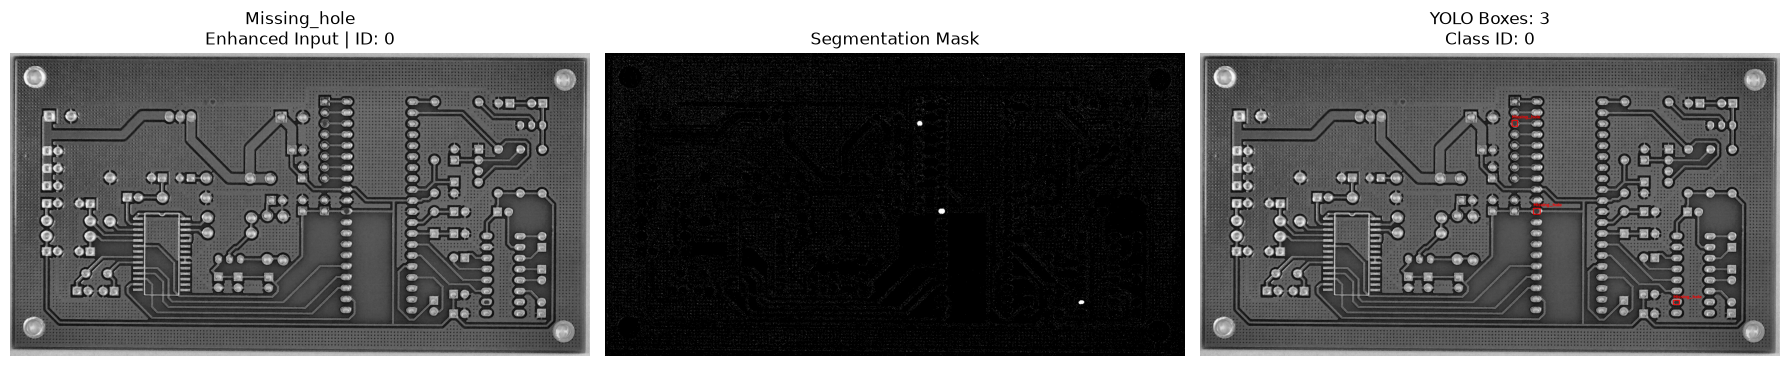


Processing: Mouse_bite
YOLO Class ID: 1
PCB ID: 05
Segmentation image: 05_mouse_bite_01.jpg
Enhanced image: C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\images\train\05_mouse_bite_01.jpg

Detected bounding boxes: 5

YOLO labels:
------------------------------------------
1 0.735849 0.628942 0.020440 0.008349
1 0.270440 0.464750 0.013365 0.008349
1 0.489190 0.395872 0.006682 0.018089
1 0.630503 0.298469 0.011792 0.009740
1 0.369890 0.138451 0.014151 0.014378

Label saved:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\yolo_test_labels\05_mouse_bite_01.txt


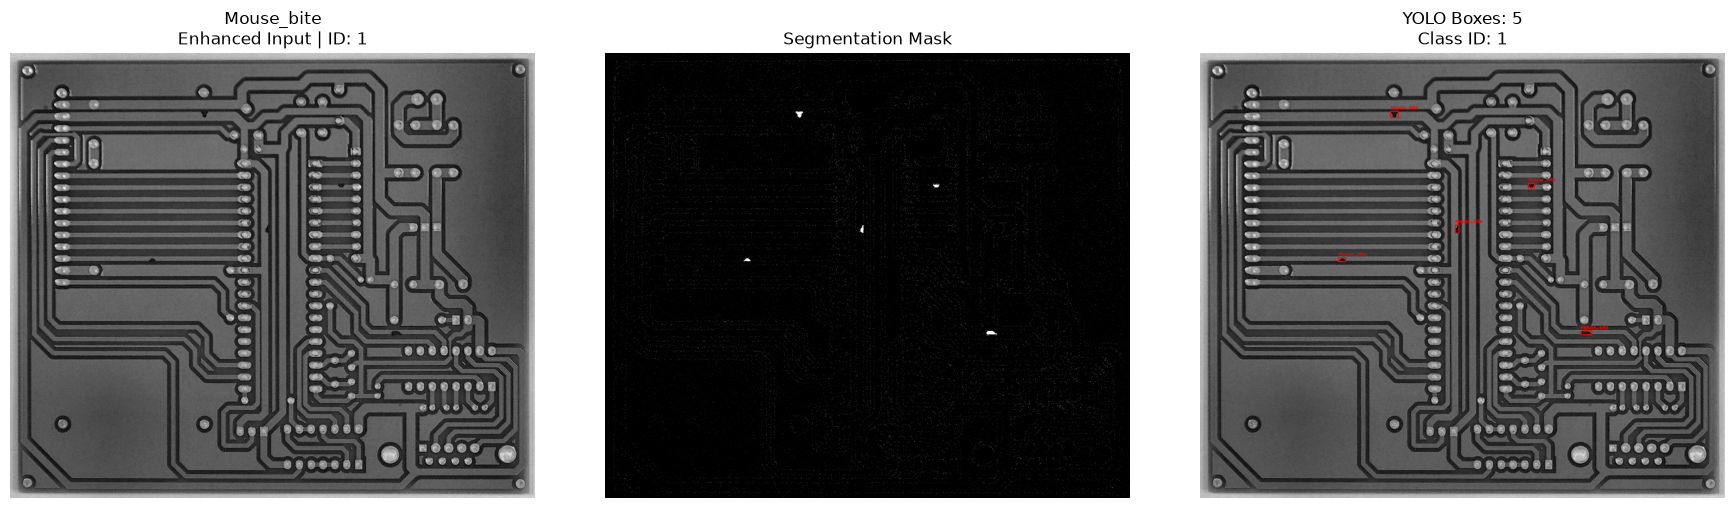


Processing: Open_circuit
YOLO Class ID: 2
PCB ID: 06
Segmentation image: 06_open_circuit_01.jpg
Enhanced image: C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\images\train\06_open_circuit_01.jpg

Detected bounding boxes: 6

YOLO labels:
------------------------------------------
2 0.559275 0.761010 0.008368 0.010794
2 0.527371 0.673143 0.007322 0.007772
2 0.348675 0.585924 0.006276 0.011226
2 0.488842 0.475173 0.007671 0.008204
2 0.592050 0.350389 0.006974 0.009067
2 0.368724 0.231218 0.010809 0.010794

Label saved:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\yolo_test_labels\06_open_circuit_01.txt


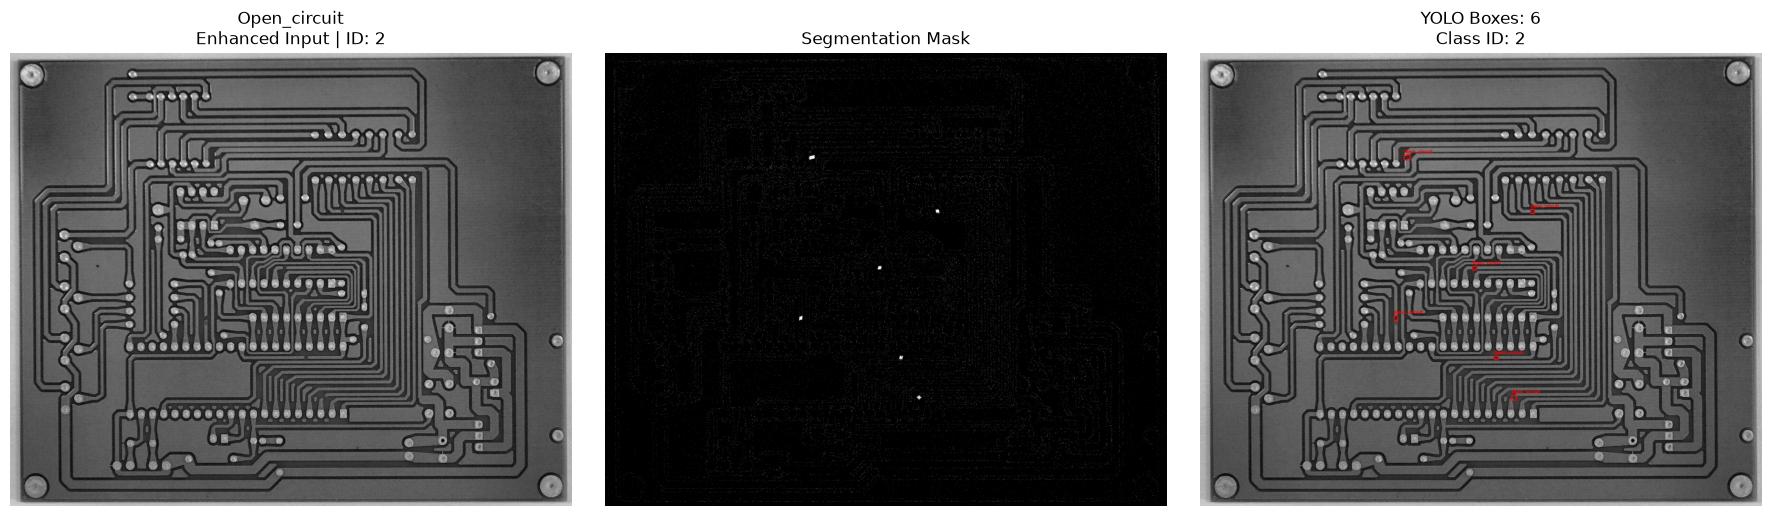


Processing: Short
YOLO Class ID: 3
PCB ID: 07
Segmentation image: 07_short_01.jpg
Enhanced image: C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\images\train\07_short_01.jpg

Detected bounding boxes: 5

YOLO labels:
------------------------------------------
3 0.659780 0.505466 0.006887 0.013535
3 0.437844 0.475273 0.005854 0.009370
3 0.668733 0.395107 0.008953 0.010411
3 0.163567 0.347215 0.022727 0.017699
3 0.326963 0.202499 0.009986 0.010411

Label saved:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\yolo_test_labels\07_short_01.txt


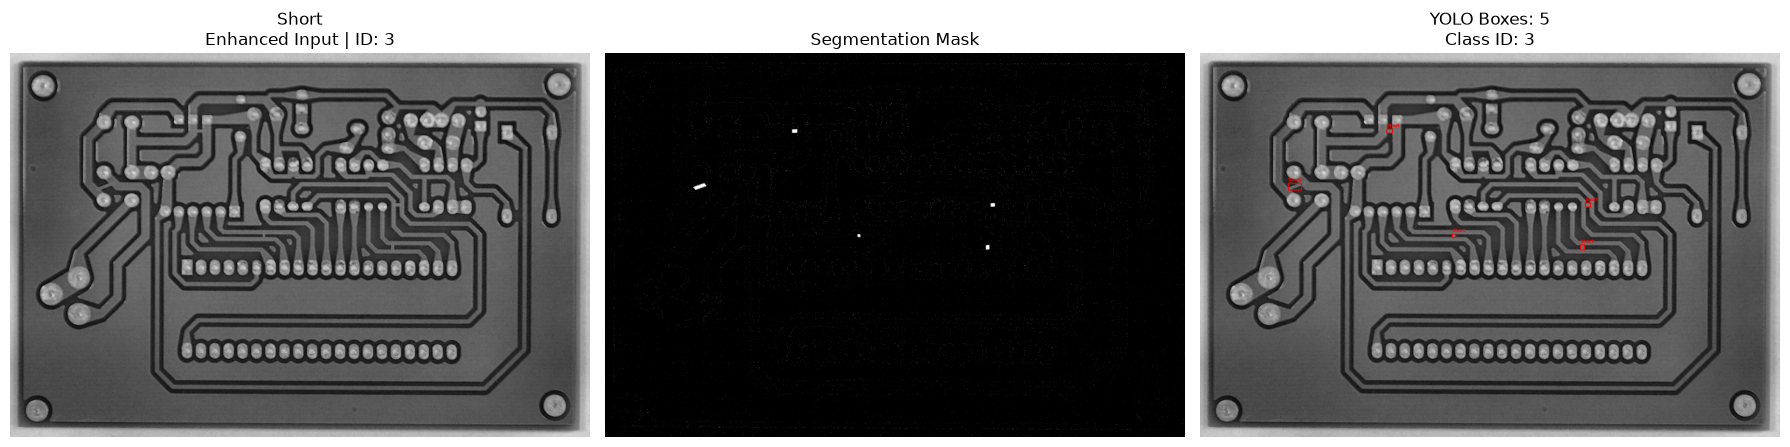


Processing: Spur
YOLO Class ID: 4
PCB ID: 08
Segmentation image: 08_spur_01.jpg
Enhanced image: C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\images\train\08_spur_01.jpg

Detected bounding boxes: 5

YOLO labels:
------------------------------------------
4 0.234686 0.909703 0.022109 0.006035
4 0.867524 0.622563 0.006162 0.029712
4 0.362269 0.583101 0.019210 0.006500
4 0.580464 0.553389 0.003987 0.026927
4 0.760783 0.351207 0.004349 0.031105

Label saved:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\yolo_test_labels\08_spur_01.txt


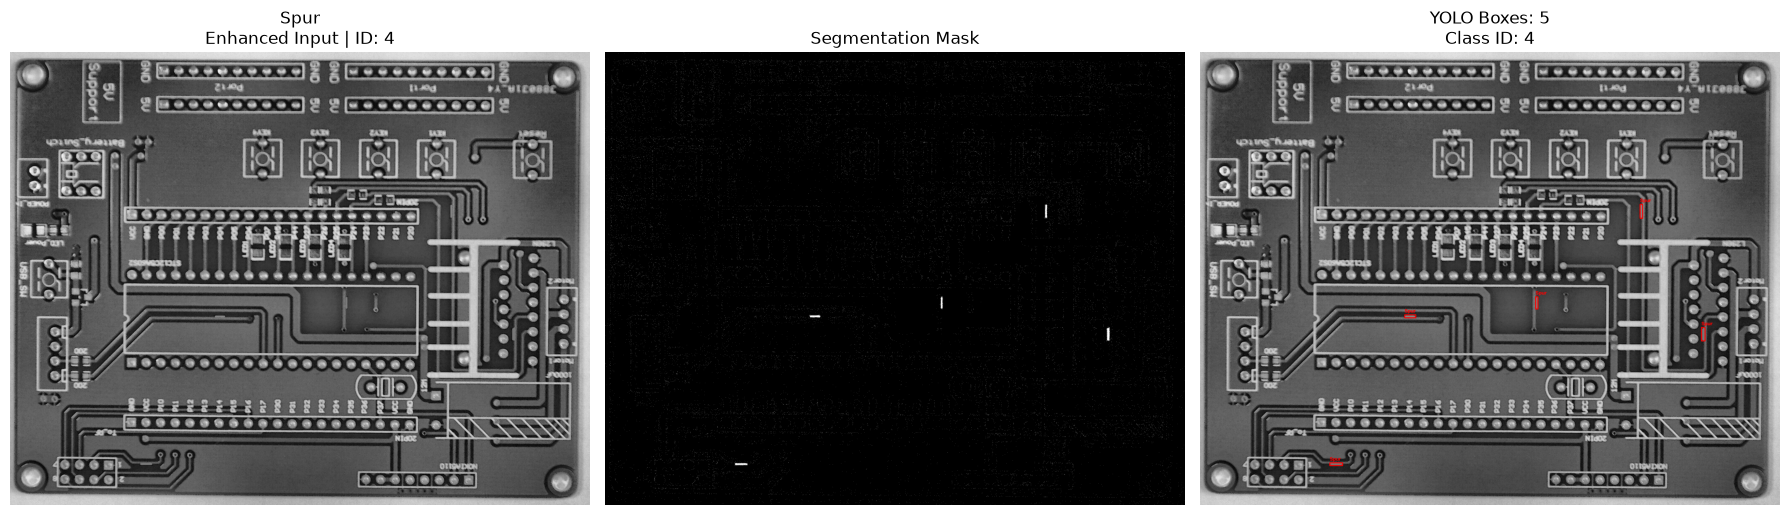


Processing: Spurious_copper
YOLO Class ID: 5
PCB ID: 09
Segmentation image: 09_spurious_copper_01.jpg
Enhanced image: C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\images\train\09_spurious_copper_01.jpg

Detected bounding boxes: 5

YOLO labels:
------------------------------------------
5 0.790991 0.504632 0.005766 0.040296
5 0.489189 0.485410 0.032793 0.007411
5 0.919640 0.404354 0.005766 0.043539
5 0.301802 0.211440 0.005405 0.036591
5 0.705225 0.095878 0.005045 0.034275

Label saved:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\yolo_test_labels\09_spurious_copper_01.txt


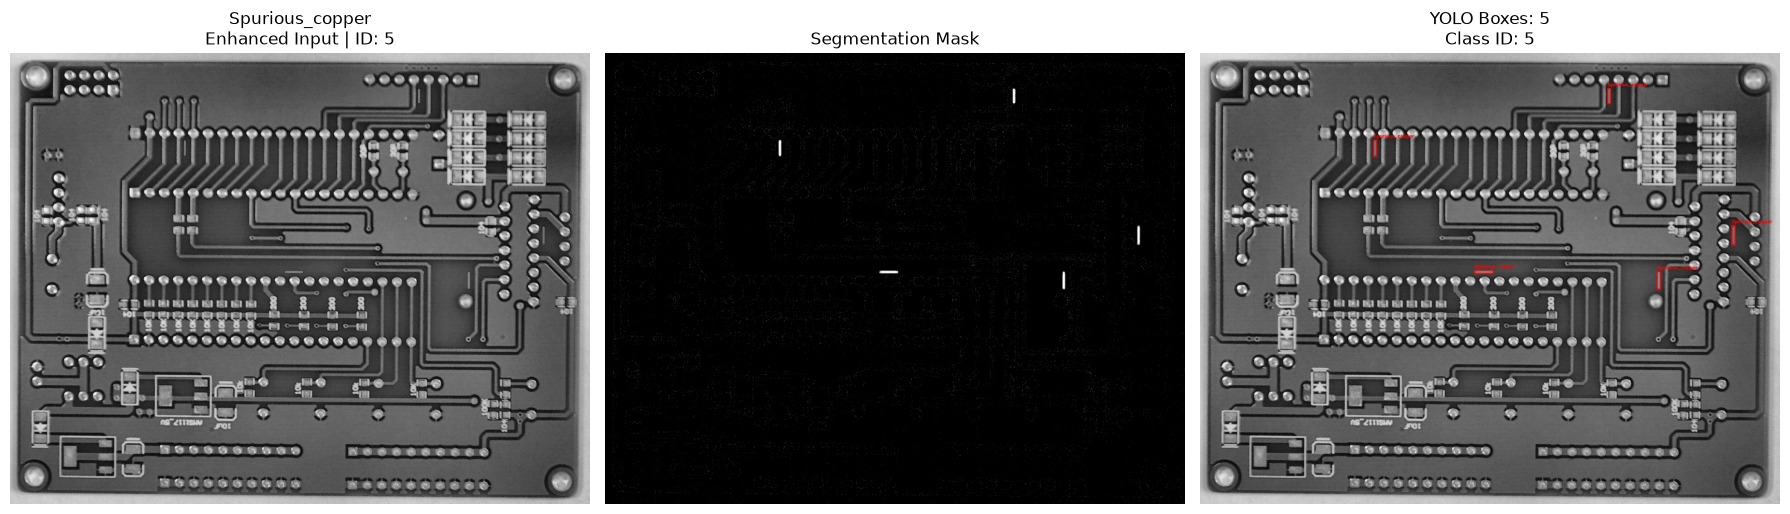


6-CLASS TEST COMPLETED
Test labels saved in:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1\yolo_test_labels


In [4]:
# ==========================================
# TEST: Segmentation → YOLO Labels
# One sample from ALL 6 defect classes
#
# Each defect has:
#   - Different YOLO Class ID
#   - Different PCB ID where possible
#
# This is ONLY a test.
# ==========================================

import cv2
import matplotlib.pyplot as plt
from pathlib import Path


# ==========================================
# 1. Paths
# ==========================================

BASE_DIR = Path(
    r"C:\Users\szepi\Downloads\PCB-Defect-Inspection"
    r"\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1"
)

SEGMENTATION_DIR = (
    BASE_DIR
    / "segmentation"
    / "train"
)

ENHANCED_DIR = (
    BASE_DIR
    / "images"
    / "train"
)

YOLO_TEST_LABEL_DIR = (
    BASE_DIR
    / "yolo_test_labels"
)

YOLO_TEST_LABEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================
# 2. YOLO Class IDs
# ==========================================

class_names = {

    "Missing_hole": 0,

    "Mouse_bite": 1,

    "Open_circuit": 2,

    "Short": 3,

    "Spur": 4,

    "Spurious_copper": 5
}


# ==========================================
# 3. Defect Classes
# ==========================================

defect_classes = [

    "Missing_hole",

    "Mouse_bite",

    "Open_circuit",

    "Short",

    "Spur",

    "Spurious_copper"
]


# ==========================================
# 4. Get Segmentation Images
# ==========================================

segmentation_files = sorted(

    [

        file

        for file
        in SEGMENTATION_DIR.iterdir()

        if file.is_file()

        and file.suffix.lower()
        in [
            ".jpg",
            ".jpeg",
            ".png"
        ]

    ]

)


print(
    "Total segmentation images:",
    len(segmentation_files)
)


# ==========================================
# 5. Select ONE DIFFERENT PCB ID
#    for each defect class
# ==========================================

selected_samples = {}

used_pcb_ids = set()


for defect_class in defect_classes:

    # Find all images belonging
    # to this defect class

    matching_files = [

        file

        for file
        in segmentation_files

        if defect_class.lower()
        in file.stem.lower()

    ]


    if len(matching_files) == 0:

        print(
            "No segmentation image found:",
            defect_class
        )

        continue


    # --------------------------------------
    # Try to choose a PCB ID that hasn't
    # already been used
    # --------------------------------------

    selected_file = None


    for file in matching_files:

        pcb_id = file.stem[:2]

        if pcb_id not in used_pcb_ids:

            selected_file = file

            used_pcb_ids.add(
                pcb_id
            )

            break


    # --------------------------------------
    # If all IDs were already used,
    # use the first available sample
    # --------------------------------------

    if selected_file is None:

        selected_file = matching_files[0]


    selected_samples[defect_class] = (
        selected_file
    )


# ==========================================
# 6. Print Selected Samples
# ==========================================

print()
print(
    "=========================================="
)

print(
    "SELECTED TEST SAMPLES"
)

print(
    "=========================================="
)

print(
    f"{'Defect':20}"
    f"{'Class ID':10}"
    f"{'PCB ID':10}"
    f"Filename"
)

print(
    "------------------------------------------"
)


for defect_class in defect_classes:

    if defect_class not in selected_samples:
        continue

    file = selected_samples[
        defect_class
    ]

    pcb_id = file.stem[:2]

    class_id = class_names[
        defect_class
    ]

    print(
        f"{defect_class:20}"
        f"{class_id:<10}"
        f"{pcb_id:<10}"
        f"{file.name}"
    )


print(
    "=========================================="
)


# ==========================================
# 7. Process Each Selected Sample
# ==========================================

for defect_class in defect_classes:

    if defect_class not in selected_samples:

        continue


    segmentation_path = (
        selected_samples[
            defect_class
        ]
    )


    print()
    print(
        "=========================================="
    )

    print(
        "Processing:",
        defect_class
    )

    print(
        "=========================================="
    )


    # ======================================
    # PCB ID
    # ======================================

    pcb_id = (
        segmentation_path.stem[:2]
    )


    class_id = (
        class_names[defect_class]
    )


    print(
        "YOLO Class ID:",
        class_id
    )

    print(
        "PCB ID:",
        pcb_id
    )

    print(
        "Segmentation image:",
        segmentation_path.name
    )


    # ======================================
    # Find matching enhanced image
    # ======================================

    enhanced_matches = [

        file

        for file
        in ENHANCED_DIR.rglob(
            segmentation_path.name
        )

        if file.is_file()

    ]


    if len(enhanced_matches) == 0:

        print(
            "Enhanced image not found."
        )

        continue


    enhanced_path = (
        enhanced_matches[0]
    )


    print(
        "Enhanced image:",
        enhanced_path
    )


    # ======================================
    # Load images
    # ======================================

    mask = cv2.imread(

        str(segmentation_path),

        cv2.IMREAD_GRAYSCALE
    )


    enhanced = cv2.imread(

        str(enhanced_path)
    )


    if mask is None:

        print(
            "Cannot load segmentation."
        )

        continue


    if enhanced is None:

        print(
            "Cannot load enhanced image."
        )

        continue


    # ======================================
    # Image dimensions
    # ======================================

    image_height, image_width = (
        enhanced.shape[:2]
    )


    # ======================================
    # Resize segmentation if needed
    # ======================================

    if mask.shape != (
        image_height,
        image_width
    ):

        mask = cv2.resize(

            mask,

            (
                image_width,
                image_height
            ),

            interpolation=cv2.INTER_NEAREST
        )


    # ======================================
    # Binary segmentation
    # ======================================

    _, binary = cv2.threshold(

        mask,

        127,

        255,

        cv2.THRESH_BINARY
    )


    # ======================================
    # Find contours
    # ======================================

    contours, _ = cv2.findContours(

        binary,

        cv2.RETR_EXTERNAL,

        cv2.CHAIN_APPROX_SIMPLE
    )


    # ======================================
    # Generate YOLO labels
    # ======================================

    labels = []


    MIN_AREA = 20


    for contour in contours:

        area = cv2.contourArea(
            contour
        )


        # Ignore very small noise

        if area < MIN_AREA:

            continue


        # ----------------------------------
        # Bounding box
        # ----------------------------------

        x, y, w, h = (
            cv2.boundingRect(contour)
        )


        # ----------------------------------
        # YOLO center coordinates
        # ----------------------------------

        x_center = (
            x + w / 2
        )

        y_center = (
            y + h / 2
        )


        # ----------------------------------
        # Normalize
        # ----------------------------------

        x_center_normalized = (
            x_center / image_width
        )

        y_center_normalized = (
            y_center / image_height
        )

        width_normalized = (
            w / image_width
        )

        height_normalized = (
            h / image_height
        )


        labels.append(

            (
                class_id,

                x_center_normalized,

                y_center_normalized,

                width_normalized,

                height_normalized
            )
        )


    # ======================================
    # Print generated labels
    # ======================================

    print()

    print(
        "Detected bounding boxes:",
        len(labels)
    )

    print()

    print(
        "YOLO labels:"
    )

    print(
        "------------------------------------------"
    )


    for label in labels:

        print(

            f"{label[0]} "
            f"{label[1]:.6f} "
            f"{label[2]:.6f} "
            f"{label[3]:.6f} "
            f"{label[4]:.6f}"
        )


    # ======================================
    # Save TEST YOLO label
    # ======================================

    label_path = (

        YOLO_TEST_LABEL_DIR
        / (
            segmentation_path.stem
            + ".txt"
        )
    )


    with open(
        label_path,
        "w"
    ) as file:

        for label in labels:

            file.write(

                f"{label[0]} "
                f"{label[1]:.6f} "
                f"{label[2]:.6f} "
                f"{label[3]:.6f} "
                f"{label[4]:.6f}\n"
            )


    print()

    print(
        "Label saved:"
    )

    print(
        label_path
    )


    # ======================================
    # Draw YOLO boxes
    # ======================================

    enhanced_rgb = cv2.cvtColor(

        enhanced,

        cv2.COLOR_BGR2RGB
    )


    result = enhanced_rgb.copy()


    for label in labels:

        (
            _,
            xc,
            yc,
            wn,
            hn
        ) = label


        # YOLO → pixel coordinates

        center_x = (
            xc * image_width
        )

        center_y = (
            yc * image_height
        )

        box_width = (
            wn * image_width
        )

        box_height = (
            hn * image_height
        )


        x1 = int(
            center_x
            - box_width / 2
        )

        y1 = int(
            center_y
            - box_height / 2
        )

        x2 = int(
            center_x
            + box_width / 2
        )

        y2 = int(
            center_y
            + box_height / 2
        )


        # ----------------------------------
        # Draw box
        # ----------------------------------

        cv2.rectangle(

            result,

            (x1, y1),

            (x2, y2),

            (255, 0, 0),

            3
        )


        # ----------------------------------
        # Draw defect class
        # ----------------------------------

        cv2.putText(

            result,

            defect_class,

            (
                x1,
                max(y1 - 10, 20)
            ),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.8,

            (255, 0, 0),

            2
        )


    # ======================================
    # Display
    # ======================================

    plt.figure(
        figsize=(18, 5)
    )


    # --------------------------------------
    # Enhanced Image
    # --------------------------------------

    plt.subplot(
        1,
        3,
        1
    )

    plt.imshow(
        enhanced_rgb
    )

    plt.title(

        f"{defect_class}\n"
        f"Enhanced Input | ID: {class_id}"
    )

    plt.axis("off")


    # --------------------------------------
    # Segmentation Mask
    # --------------------------------------

    plt.subplot(
        1,
        3,
        2
    )

    plt.imshow(

        binary,

        cmap="gray"
    )

    plt.title(
        "Segmentation Mask"
    )

    plt.axis("off")


    # --------------------------------------
    # YOLO Bounding Boxes
    # --------------------------------------

    plt.subplot(
        1,
        3,
        3
    )

    plt.imshow(
        result
    )

    plt.title(

        f"YOLO Boxes: {len(labels)}\n"
        f"Class ID: {class_id}"
    )

    plt.axis("off")


    plt.tight_layout()

    plt.show()


# ==========================================
# Final
# ==========================================

print()
print(
    "=========================================="
)

print(
    "6-CLASS TEST COMPLETED"
)

print(
    "=========================================="
)

print(
    "Test labels saved in:"
)

print(
    YOLO_TEST_LABEL_DIR
)

print(
    "=========================================="
)

In [7]:
# ==========================================
# FULL: Segmentation → YOLO Labels
#
# Processes:
#   Set 1
#   Set 2
#   Set 3
#
# Each set:
#   train
#   val
#   test
#
# Segmentation masks
#        ↓
# Find white defect regions
#        ↓
# Bounding boxes
#        ↓
# YOLO .txt labels
#
# Existing labels folders are used.
# ==========================================

import cv2
from pathlib import Path
from tqdm import tqdm


# ==========================================
# 1. Project Directory
# ==========================================

PROJECT_DIR = Path(
    r"C:\Users\szepi\Downloads\PCB-Defect-Inspection"
    r"\PCB-Defect-Inspection"
)


# ==========================================
# 2. Dataset Sets
# ==========================================

SET_NAMES = [
    "set1",
    "set2",
    "set3"
]


# ==========================================
# 3. Dataset Splits
# ==========================================

SPLITS = [
    "train",
    "val",
    "test"
]


# ==========================================
# 4. YOLO Class IDs
# ==========================================

CLASS_IDS = {
    "Missing_hole": 0,
    "Mouse_bite": 1,
    "Open_circuit": 2,
    "Short": 3,
    "Spurious_copper": 5,
    "Spur": 4
}


# ==========================================
# IMPORTANT:
# Check longer names first.
#
# Otherwise:
# "Spur" could accidentally match
# "Spurious_copper".
# ==========================================

CLASS_NAMES_ORDERED = sorted(
    CLASS_IDS.keys(),
    key=len,
    reverse=True
)


# ==========================================
# 5. Minimum Defect Area
# ==========================================

MIN_AREA = 20


# ==========================================
# 6. Image Extensions
# ==========================================

IMAGE_EXTENSIONS = [
    ".jpg",
    ".jpeg",
    ".png"
]


# ==========================================
# 7. Find Defect Class
#    From Filename
# ==========================================

def get_defect_class(filename):

    filename_lower = filename.stem.lower()


    for class_name in CLASS_NAMES_ORDERED:

        if class_name.lower() in filename_lower:

            return class_name


    return None


# ==========================================
# 8. Process Each Dataset Set
# ==========================================

for set_name in SET_NAMES:

    print()
    print("=" * 70)
    print(
        f"PROCESSING DATASET {set_name.upper()}"
    )
    print("=" * 70)


    # --------------------------------------
    # Set directory
    # --------------------------------------

    SET_DIR = (
        PROJECT_DIR
        / "data"
        / "clean"
        / f"dataset_limszeping_{set_name}"
    )


    # --------------------------------------
    # Segmentation directory
    # --------------------------------------

    SEGMENTATION_DIR = (
        SET_DIR
        / "segmentation"
    )


    # --------------------------------------
    # Existing labels directory
    # --------------------------------------

    LABELS_DIR = (
        SET_DIR
        / "labels"
    )


    # --------------------------------------
    # Enhanced images directory
    # --------------------------------------

    IMAGES_DIR = (
        SET_DIR
        / "images"
    )


    # ======================================
    # Check required directories
    # ======================================

    print()
    print("Set directory:")
    print(SET_DIR)

    print()
    print(
        "Segmentation exists:",
        SEGMENTATION_DIR.exists()
    )

    print(
        "Images exists:",
        IMAGES_DIR.exists()
    )

    print(
        "Labels exists:",
        LABELS_DIR.exists()
    )


    if not SEGMENTATION_DIR.exists():

        print(
            "\nSKIPPING SET:",
            set_name
        )

        print(
            "Segmentation directory not found."
        )

        continue


    if not LABELS_DIR.exists():

        print(
            "\nERROR:"
        )

        print(
            "Existing labels folder not found:"
        )

        print(
            LABELS_DIR
        )

        continue


    # ======================================
    # Set statistics
    # ======================================

    total_processed = 0
    total_skipped = 0
    total_boxes = 0


    # ======================================
    # Process train / val / test
    # ======================================

    for split in SPLITS:

        print()
        print("-" * 60)
        print(
            f"{set_name.upper()} - {split.upper()}"
        )
        print("-" * 60)


        # ----------------------------------
        # Segmentation split
        # ----------------------------------

        segmentation_split_dir = (
            SEGMENTATION_DIR
            / split
        )


        # ----------------------------------
        # Existing labels split
        # ----------------------------------

        labels_split_dir = (
            LABELS_DIR
            / split
        )


        # ----------------------------------
        # Images split
        # ----------------------------------

        images_split_dir = (
            IMAGES_DIR
            / split
        )


        # ==================================
        # Check segmentation split
        # ==================================

        if not segmentation_split_dir.exists():

            print(
                "Segmentation split not found:"
            )

            print(
                segmentation_split_dir
            )

            continue


        # ==================================
        # Create labels/train
        # labels/val
        # labels/test
        #
        # Only if they don't exist.
        # ==================================

        labels_split_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        # ==================================
        # Get segmentation files
        # ==================================

        segmentation_files = sorted(

            [
                file

                for file
                in segmentation_split_dir.iterdir()

                if file.is_file()

                and file.suffix.lower()
                in IMAGE_EXTENSIONS
            ]
        )


        print(
            "Segmentation images:",
            len(segmentation_files)
        )


        if len(segmentation_files) == 0:

            print(
                "No segmentation images found."
            )

            continue


        # ==================================
        # Process each segmentation image
        # ==================================

        processed_count = 0
        skipped_count = 0
        box_count = 0


        for segmentation_path in tqdm(

            segmentation_files,

            desc=f"{set_name} - {split}"
        ):


            # ==================================
            # Determine defect class
            # ==================================

            defect_class = get_defect_class(
                segmentation_path
            )


            if defect_class is None:

                print(
                    "\nSkipped:"
                    f" {segmentation_path.name}"
                )

                print(
                    "Cannot determine defect class."
                )

                skipped_count += 1

                continue


            class_id = CLASS_IDS[
                defect_class
            ]


            # ==================================
            # Find corresponding enhanced image
            #
            # Search recursively inside
            # images/split.
            # ==================================

            if not images_split_dir.exists():

                print(
                    "\nImages directory not found:"
                )

                print(
                    images_split_dir
                )

                skipped_count += 1

                continue


            enhanced_matches = list(

                images_split_dir.rglob(
                    segmentation_path.name
                )
            )


            if len(enhanced_matches) == 0:

                print(
                    "\nSkipped - enhanced image "
                    "not found:"
                )

                print(
                    segmentation_path.name
                )

                skipped_count += 1

                continue


            enhanced_path = (
                enhanced_matches[0]
            )


            # ==================================
            # Load segmentation mask
            # ==================================

            mask = cv2.imread(

                str(segmentation_path),

                cv2.IMREAD_GRAYSCALE
            )


            if mask is None:

                print(
                    "\nSkipped - cannot load mask:"
                )

                print(
                    segmentation_path.name
                )

                skipped_count += 1

                continue


            # ==================================
            # Load enhanced image
            # ==================================

            enhanced = cv2.imread(

                str(enhanced_path)
            )


            if enhanced is None:

                print(
                    "\nSkipped - cannot load "
                    "enhanced image:"
                )

                print(
                    enhanced_path
                )

                skipped_count += 1

                continue


            # ==================================
            # Image dimensions
            # ==================================

            image_height, image_width = (
                enhanced.shape[:2]
            )


            # ==================================
            # Resize segmentation mask
            # if necessary
            # ==================================

            if mask.shape != (
                image_height,
                image_width
            ):

                mask = cv2.resize(

                    mask,

                    (
                        image_width,
                        image_height
                    ),

                    interpolation=cv2.INTER_NEAREST
                )


            # ==================================
            # Binary segmentation
            # ==================================

            _, binary = cv2.threshold(

                mask,

                127,

                255,

                cv2.THRESH_BINARY
            )


            # ==================================
            # Find defect contours
            # ==================================

            contours, _ = cv2.findContours(

                binary,

                cv2.RETR_EXTERNAL,

                cv2.CHAIN_APPROX_SIMPLE
            )


            # ==================================
            # Generate YOLO labels
            # ==================================

            labels = []


            for contour in contours:

                area = cv2.contourArea(
                    contour
                )


                # Remove tiny noise

                if area < MIN_AREA:

                    continue


                # ----------------------------------
                # Bounding box
                # ----------------------------------

                x, y, w, h = (
                    cv2.boundingRect(
                        contour
                    )
                )


                # ----------------------------------
                # YOLO center
                # ----------------------------------

                x_center = (
                    x + w / 2
                )

                y_center = (
                    y + h / 2
                )


                # ----------------------------------
                # Normalize
                # ----------------------------------

                x_center_normalized = (
                    x_center / image_width
                )

                y_center_normalized = (
                    y_center / image_height
                )

                width_normalized = (
                    w / image_width
                )

                height_normalized = (
                    h / image_height
                )


                # ----------------------------------
                # Add YOLO label
                # ----------------------------------

                labels.append(

                    (
                        class_id,

                        x_center_normalized,

                        y_center_normalized,

                        width_normalized,

                        height_normalized
                    )
                )


            # ==================================
            # Save YOLO .txt
            # ==================================

            label_path = (

                labels_split_dir
                / (
                    segmentation_path.stem
                    + ".txt"
                )
            )


            with open(
                label_path,
                "w"
            ) as file:

                for label in labels:

                    (
                        class_id,
                        xc,
                        yc,
                        w,
                        h
                    ) = label


                    file.write(

                        f"{class_id} "
                        f"{xc:.6f} "
                        f"{yc:.6f} "
                        f"{w:.6f} "
                        f"{h:.6f}\n"
                    )


            # ==================================
            # Statistics
            # ==================================

            processed_count += 1

            box_count += len(labels)


        # ==================================
        # Split summary
        # ==================================

        print()

        print(
            f"{set_name.upper()} - "
            f"{split.upper()} COMPLETED"
        )

        print(
            "Labels generated:",
            processed_count
        )

        print(
            "Bounding boxes generated:",
            box_count
        )

        print(
            "Skipped:",
            skipped_count
        )


        # Add to set totals

        total_processed += (
            processed_count
        )

        total_skipped += (
            skipped_count
        )

        total_boxes += (
            box_count
        )


    # ======================================
    # Set summary
    # ======================================

    print()
    print("=" * 70)
    print(
        f"{set_name.upper()} SUMMARY"
    )
    print("=" * 70)

    print(
        "Total labels generated:",
        total_processed
    )

    print(
        "Total bounding boxes:",
        total_boxes
    )

    print(
        "Total skipped:",
        total_skipped
    )

    print()

    print(
        "Labels saved in:"
    )

    print(
        LABELS_DIR
    )


# ==========================================
# Final Summary
# ==========================================

print()
print("=" * 70)
print("ALL 3 DATASETS - LABEL GENERATION COMPLETED")
print("=" * 70)

print(
    "Set 1, Set 2 and Set 3 have been processed."
)

print(
    "YOLO labels are stored in the existing"
)

print(
    "labels/train, labels/val and labels/test"
)

print("=" * 70)


PROCESSING DATASET SET1

Set directory:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set1

Segmentation exists: True
Images exists: True
Labels exists: True

------------------------------------------------------------
SET1 - TRAIN
------------------------------------------------------------
Segmentation images: 481


set1 - train: 100%|██████████| 481/481 [02:59<00:00,  2.68it/s]



SET1 - TRAIN COMPLETED
Labels generated: 481
Bounding boxes generated: 4377
Skipped: 0

------------------------------------------------------------
SET1 - VAL
------------------------------------------------------------
Segmentation images: 60


set1 - val: 100%|██████████| 60/60 [00:25<00:00,  2.37it/s]



SET1 - VAL COMPLETED
Labels generated: 60
Bounding boxes generated: 315
Skipped: 0

------------------------------------------------------------
SET1 - TEST
------------------------------------------------------------
Segmentation images: 152


...


SET3 - TRAIN COMPLETED
Labels generated: 481
Bounding boxes generated: 4508
Skipped: 0

------------------------------------------------------------
SET3 - VAL
------------------------------------------------------------
Segmentation images: 60


set3 - val: 100%|██████████| 60/60 [02:43<00:00,  2.73s/it]



SET3 - VAL COMPLETED
Labels generated: 60
Bounding boxes generated: 320
Skipped: 0

------------------------------------------------------------
SET3 - TEST
------------------------------------------------------------
Segmentation images: 152


set3 - test: 100%|██████████| 152/152 [00:43<00:00,  3.48it/s]


SET3 - TEST COMPLETED
Labels generated: 152
Bounding boxes generated: 1442
Skipped: 0

SET3 SUMMARY
Total labels generated: 693
Total bounding boxes: 6270
Total skipped: 0

Labels saved in:
C:\Users\szepi\Downloads\PCB-Defect-Inspection\PCB-Defect-Inspection\data\clean\dataset_limszeping_set3\labels

ALL 3 DATASETS - LABEL GENERATION COMPLETED
Set 1, Set 2 and Set 3 have been processed.
YOLO labels are stored in the existing
labels/train, labels/val and labels/test
